# 04b — Hyperparameter Tuning v2 (Optuna + Spatial GroupKFold)

Inputs: `train_v2.csv`, `test_v2.csv`, `selected_features_v2.json`

Tunes RF, XGBoost, LightGBM with Optuna (50 trials each).  
Objective: maximise mean AUC-ROC on **GroupKFold(5)** spatial CV using `block_id`.  
Best models saved to `models/{name}_v2_best.pkl`; all runs logged to MLflow.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid', font_scale=1.1)

PROCESSED  = Path('../data/processed')
OUTPUTS    = Path('../outputs')
MODELS_DIR = Path('../models')
MLRUNS_DIR = Path('../mlruns')
OUTPUTS.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS     = 5
N_TRIALS     = 20        # increase to 50-100 for final paper run
EXPERIMENT   = 'wildfires-cordoba'

print('All imports OK')

All imports OK


## 1. Load Data

In [2]:
with open(PROCESSED / 'selected_features_v2.json') as f:
    feature_meta = json.load(f)

MODEL_FEATURES = feature_meta['all_model_features']

train = pd.read_csv(PROCESSED / 'train_v2.csv')
test  = pd.read_csv(PROCESSED / 'test_v2.csv')

X_train        = train[MODEL_FEATURES].values
y_train        = train['label'].values
block_ids_train = train['block_id'].values

X_test  = test[MODEL_FEATURES].values
y_test  = test['label'].values

print(f'Train: {X_train.shape}  fire_rate={y_train.mean():.4f}  blocks={train["block_id"].nunique()}')
print(f'Test : {X_test.shape}   fire_rate={y_test.mean():.4f}   blocks={test["block_id"].nunique()}')
print(f'Features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}')

Train: (52904, 19)  fire_rate=0.5262  blocks=321
Test : (19392, 19)   fire_rate=0.4285   blocks=138
Features (19): ['elevation', 'slope', 'aspect_cos', 'population_density', 'clay', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km', 'lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']


## 2. MLflow Setup

In [3]:
mlflow.set_tracking_uri(f'file://{MLRUNS_DIR.resolve()}')
mlflow.set_experiment(EXPERIMENT)

exp = mlflow.get_experiment_by_name(EXPERIMENT)
print(f'Experiment: {EXPERIMENT}  (ID: {exp.experiment_id})')

Experiment: wildfires-cordoba  (ID: 310954585512672985)


## 3. Optuna Objective Helpers

In [4]:
GKF = GroupKFold(n_splits=CV_FOLDS)


def cv_auc(model):
    """Mean GroupKFold AUC-ROC on the training set."""
    scores = cross_val_score(
        model, X_train, y_train,
        cv=GKF, groups=block_ids_train,
        scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()


# ── Random Forest ────────────────────────────────────────────────────────────
def rf_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 300, step=50),  # capped for speed
        max_depth         = trial.suggest_int('max_depth', 5, 20),
        min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5]),
        class_weight      = trial.suggest_categorical('class_weight', [None, 'balanced']),
        n_jobs=-1, random_state=RANDOM_STATE
    )
    return cv_auc(RandomForestClassifier(**params))


# ── XGBoost ──────────────────────────────────────────────────────────────────
def xgb_objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 100, 500, step=50),
        max_depth         = trial.suggest_int('max_depth', 3, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0.0, 5.0),
        eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE
    )
    return cv_auc(XGBClassifier(**params))


# ── LightGBM ─────────────────────────────────────────────────────────────────
def lgbm_objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 500, step=50),
        num_leaves       = trial.suggest_int('num_leaves', 20, 200),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        reg_alpha        = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        reg_lambda       = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        min_child_samples= trial.suggest_int('min_child_samples', 10, 100),
        max_depth        = trial.suggest_int('max_depth', -1, 15),
        class_weight     = trial.suggest_categorical('class_weight', [None, 'balanced']),
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1
    )
    return cv_auc(LGBMClassifier(**params))


print('Objective functions defined.')

Objective functions defined.


## 4. Run Optuna Studies

Each study maximises GroupKFold AUC-ROC with `N_TRIALS` trials.  
Set `N_TRIALS = 100` for the final paper run.

In [5]:
# ── Random Forest ────────────────────────────────────────────────────────────
print(f'Tuning RandomForest ({N_TRIALS} trials)...')
study_rf = optuna.create_study(direction='maximize', study_name='rf_v2',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_rf.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_rf_params = study_rf.best_params
best_rf_auc    = study_rf.best_value
print(f'\nBest RF CV AUC: {best_rf_auc:.4f}')
print(f'Best RF params: {best_rf_params}')

Tuning RandomForest (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


...

/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

/Users/gerardoaboulafia/opt/anaconda3/envs/py311_ds/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(



Best RF CV AUC: 0.7481
Best RF params: {'n_estimators': 300, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 0.3, 'class_weight': None}


In [6]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
print(f'Tuning XGBoost ({N_TRIALS} trials)...')
study_xgb = optuna.create_study(direction='maximize', study_name='xgb_v2',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_auc    = study_xgb.best_value
print(f'\nBest XGB CV AUC: {best_xgb_auc:.4f}')
print(f'Best XGB params: {best_xgb_params}')

Tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


Best XGB CV AUC: 0.7391
Best XGB params: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.06333268775321842, 'subsample': 0.5704621124873813, 'colsample_bytree': 0.8813181884524238, 'reg_alpha': 4.6876566400928895e-08, 'reg_lambda': 7.620481786158549, 'min_child_weight': 8, 'gamma': 0.993578407670862}


In [7]:
# ── LightGBM ─────────────────────────────────────────────────────────────────
print(f'Tuning LightGBM ({N_TRIALS} trials)...')
study_lgbm = optuna.create_study(direction='maximize', study_name='lgbm_v2',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgbm.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_lgbm_params = study_lgbm.best_params
best_lgbm_auc    = study_lgbm.best_value
print(f'\nBest LGBM CV AUC: {best_lgbm_auc:.4f}')
print(f'Best LGBM params: {best_lgbm_params}')

Tuning LightGBM (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]


Best LGBM CV AUC: 0.7397
Best LGBM params: {'n_estimators': 200, 'num_leaves': 86, 'learning_rate': 0.04717052037625178, 'subsample': 0.8925879806965068, 'colsample_bytree': 0.5198042692950159, 'reg_alpha': 0.00042472707398058225, 'reg_lambda': 0.0021465011216654484, 'min_child_samples': 14, 'max_depth': 9, 'class_weight': None}


## 5. Retrain Best Models on Full Training Set

In [8]:
def evaluate_on_test(model):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        'test_roc_auc'  : roc_auc_score(y_test, y_prob),
        'test_accuracy' : accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred, zero_division=0),
        'test_recall'   : recall_score(y_test, y_pred, zero_division=0),
        'test_f1'       : f1_score(y_test, y_pred, zero_division=0),
    }


# Retrain on full train set
best_rf   = RandomForestClassifier(**best_rf_params, n_jobs=-1, random_state=RANDOM_STATE)
best_xgb  = XGBClassifier(**best_xgb_params, eval_metric='logloss',
                           n_jobs=-1, random_state=RANDOM_STATE)
best_lgbm = LGBMClassifier(**best_lgbm_params, n_jobs=-1,
                            random_state=RANDOM_STATE, verbose=-1)

print('Training best RF...', end=' ', flush=True)
best_rf.fit(X_train, y_train)
rf_holdout = evaluate_on_test(best_rf)
print(f'Test AUC={rf_holdout["test_roc_auc"]:.4f}')

print('Training best XGBoost...', end=' ', flush=True)
best_xgb.fit(X_train, y_train)
xgb_holdout = evaluate_on_test(best_xgb)
print(f'Test AUC={xgb_holdout["test_roc_auc"]:.4f}')

print('Training best LightGBM...', end=' ', flush=True)
best_lgbm.fit(X_train, y_train)
lgbm_holdout = evaluate_on_test(best_lgbm)
print(f'Test AUC={lgbm_holdout["test_roc_auc"]:.4f}')

Training best RF... 

Test AUC=0.6976
Training best XGBoost... 

Test AUC=0.6862
Training best LightGBM... 

Test AUC=0.6912


## 6. Log Best Runs to MLflow

In [9]:
def log_tuned_run(name, model, best_params, cv_auc_best, holdout):
    with mlflow.start_run(run_name=f'{name}_v2_tuned') as run:
        mlflow.set_tag('phase', 'v2_tuned')
        mlflow.set_tag('model', name)
        mlflow.set_tag('cv_type', 'GroupKFold_spatial')
        mlflow.set_tag('n_trials', str(N_TRIALS))
        for k, v in best_params.items():
            mlflow.log_param(k, v)
        mlflow.log_metric('cv_auc_best', cv_auc_best)
        for k, v in holdout.items():
            mlflow.log_metric(k, v)
        mlflow.sklearn.log_model(model, artifact_path='model')
        return run.info.run_id


run_rf   = log_tuned_run('RandomForest', best_rf,   best_rf_params,   best_rf_auc,   rf_holdout)
run_xgb  = log_tuned_run('XGBoost',     best_xgb,  best_xgb_params,  best_xgb_auc,  xgb_holdout)
run_lgbm = log_tuned_run('LightGBM',    best_lgbm, best_lgbm_params, best_lgbm_auc, lgbm_holdout)

print('MLflow runs logged.')

2026/04/10 21:48:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/10 21:48:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/10 21:48:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/10 21:48:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/04/10 21:48:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/10 21:48:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow runs logged.


## 7. Results Summary

In [10]:
# Load baseline metrics for comparison
with open(OUTPUTS / 'v2_baseline_metrics.json') as f:
    baseline = {r['model']: r for r in json.load(f)}

tuned_results = [
    ('RandomForest', best_rf,   best_rf_auc,   rf_holdout,   run_rf),
    ('XGBoost',     best_xgb,  best_xgb_auc,  xgb_holdout,  run_xgb),
    ('LightGBM',    best_lgbm, best_lgbm_auc, lgbm_holdout, run_lgbm),
]

rows = []
for name, model, cv_auc_val, holdout, run_id in tuned_results:
    base = baseline.get(name, {})
    rows.append({
        'Model'           : name,
        'Baseline CV AUC' : f"{base.get('cv_auc_mean', 0):.4f}",
        'Tuned CV AUC'    : f'{cv_auc_val:.4f}',
        'Baseline Test AUC': f"{base.get('test_roc_auc', 0):.4f}",
        'Tuned Test AUC'  : f"{holdout['test_roc_auc']:.4f}",
        'Test F1'         : f"{holdout['test_f1']:.4f}",
        'run_id'          : run_id,
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print('=== TUNING RESULTS vs BASELINE ===')
print(summary_df.drop(columns='run_id').to_string())
summary_df

=== TUNING RESULTS vs BASELINE ===
             Baseline CV AUC Tuned CV AUC Baseline Test AUC Tuned Test AUC Test F1
Model                                                                             
RandomForest          0.7432       0.7481            0.6992         0.6976  0.5643
XGBoost               0.7321       0.7391            0.6912         0.6862  0.5625
LightGBM              0.7283       0.7397            0.6865         0.6912  0.5677


,Baseline CV AUC,Tuned CV AUC,Baseline Test AUC,Tuned Test AUC,Test F1,run_id
Model,,,,,,
RandomForest,0.7432,0.7481,0.6992,0.6976,0.5643,d7061da07d3d49a89bddc95c86b10d5e
XGBoost,0.7321,0.7391,0.6912,0.6862,0.5625,e6263ba155fd4de4800c4366d24bb126
LightGBM,0.7283,0.7397,0.6865,0.6912,0.5677,2a837cc031a74e899cd1db761b494b56


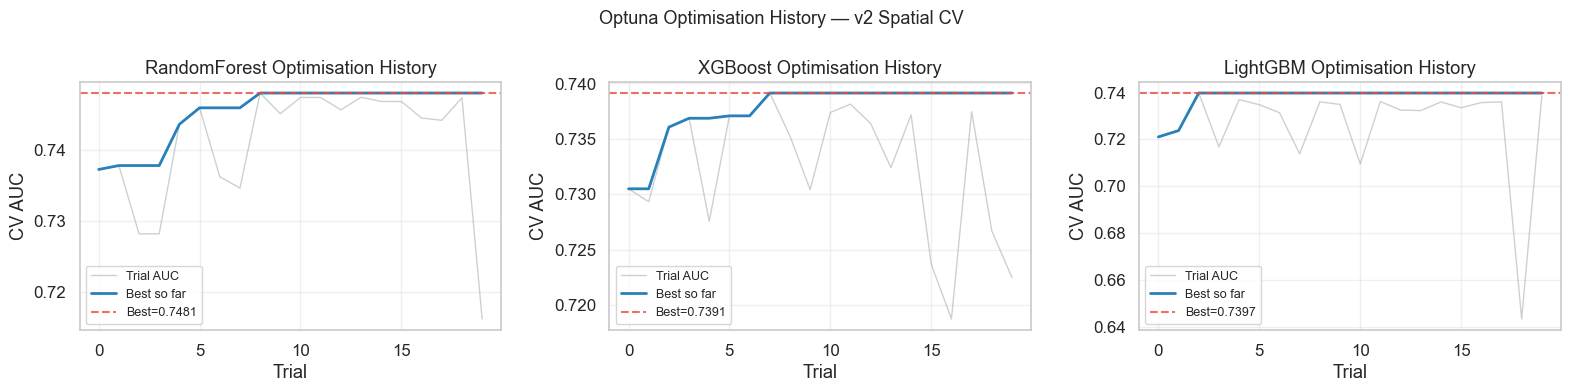

In [11]:
# Optuna optimisation history
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, study, name in [
    (axes[0], study_rf,   'RandomForest'),
    (axes[1], study_xgb,  'XGBoost'),
    (axes[2], study_lgbm, 'LightGBM'),
]:
    values   = [t.value for t in study.trials if t.value is not None]
    best_so  = np.maximum.accumulate(values)
    ax.plot(values,  alpha=0.4, color='#7f8c8d', linewidth=1, label='Trial AUC')
    ax.plot(best_so, color='#2980b9', linewidth=2, label='Best so far')
    ax.axhline(study.best_value, ls='--', color='#e74c3c', alpha=0.8,
                label=f'Best={study.best_value:.4f}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV AUC')
    ax.set_title(f'{name} Optimisation History')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Optuna Optimisation History — v2 Spatial CV', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_tuning_history.png', dpi=150, bbox_inches='tight')
plt.show()

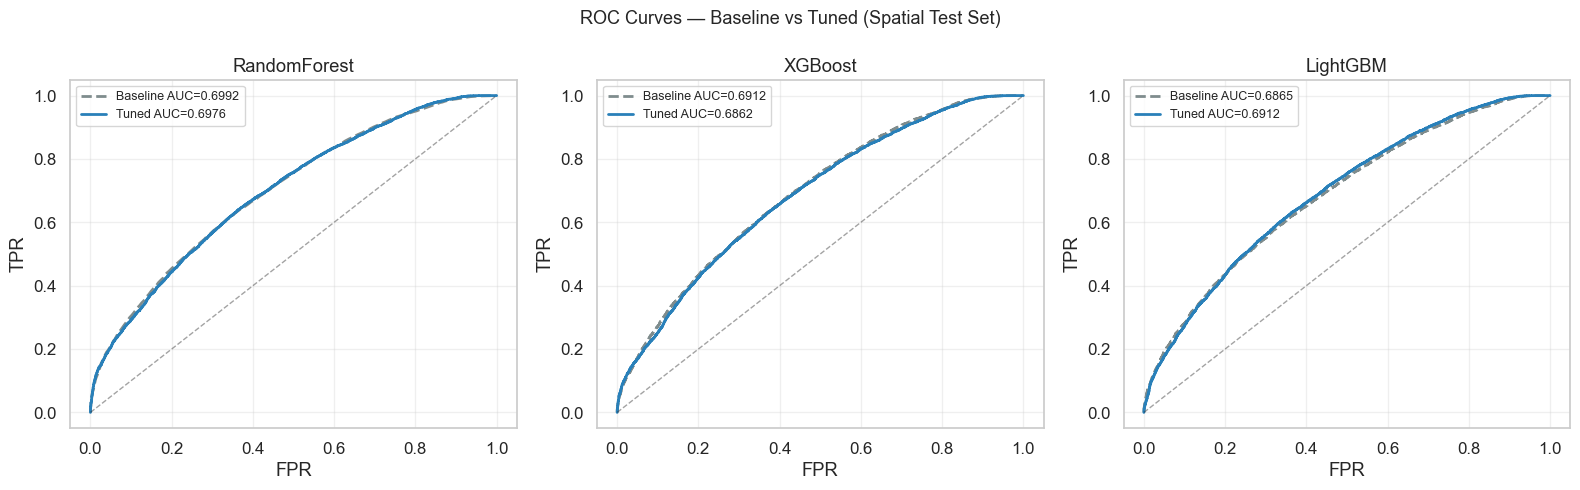

In [12]:
# ROC curves — baseline vs tuned
with open(MODELS_DIR / 'randomforest_v2_baseline.pkl', 'rb') as f:
    base_rf = pickle.load(f)
with open(MODELS_DIR / 'xgboost_v2_baseline.pkl', 'rb') as f:
    base_xgb = pickle.load(f)
with open(MODELS_DIR / 'lightgbm_v2_baseline.pkl', 'rb') as f:
    base_lgbm = pickle.load(f)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [
    ('RandomForest', base_rf,   best_rf,   axes[0]),
    ('XGBoost',      base_xgb,  best_xgb,  axes[1]),
    ('LightGBM',     base_lgbm, best_lgbm, axes[2]),
]
for name, base_m, tuned_m, ax in pairs:
    for model, label, color, ls in [
        (base_m,  'Baseline', '#7f8c8d', '--'),
        (tuned_m, 'Tuned',    '#2980b9', '-'),
    ]:
        prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, color=color, ls=ls, lw=2, label=f'{label} AUC={auc:.4f}')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — Baseline vs Tuned (Spatial Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_roc_baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

Skipping param importance plot: plot_param_importances() got an unexpected keyword argument 'ax'


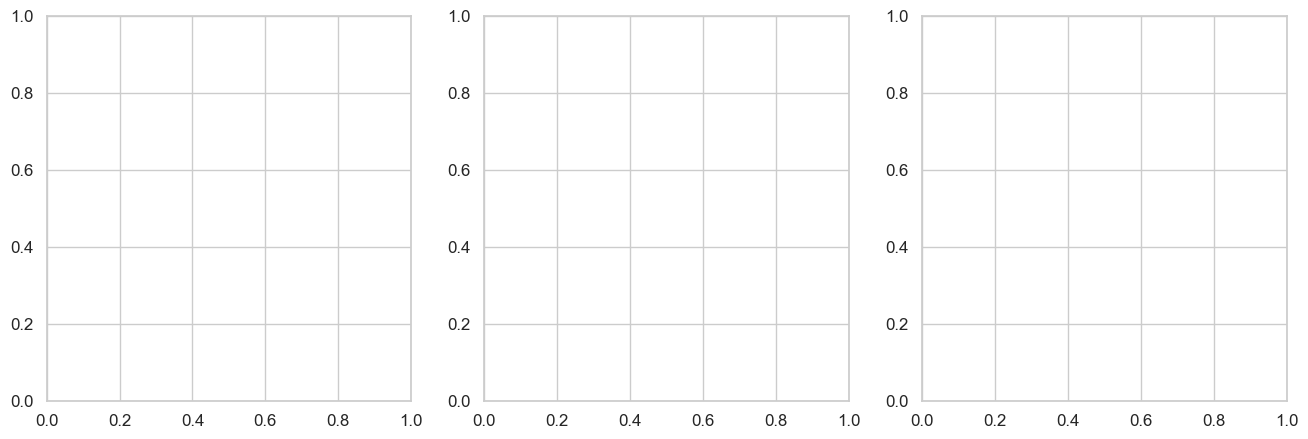

In [13]:
# Hyperparameter importance via Optuna
try:
    from optuna.visualization.matplotlib import plot_param_importances
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, study, name in [
        (axes[0], study_rf,   'RandomForest'),
        (axes[1], study_xgb,  'XGBoost'),
        (axes[2], study_lgbm, 'LightGBM'),
    ]:
        plt.sca(ax)
        plot_param_importances(study, ax=ax)
        ax.set_title(f'{name} Hyperparameter Importance')
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'v2_hyperparam_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Skipping param importance plot: {e}')

## 8. Save Best Models & Artifacts

In [14]:
# Save tuned models
for name, model in [('randomforest', best_rf), ('xgboost', best_xgb), ('lightgbm', best_lgbm)]:
    path = MODELS_DIR / f'{name}_v2_best.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {path}')

# Save tuned metrics + params
tuned_summary = []
for name, model, cv_auc_val, holdout, run_id, params in [
    ('RandomForest', best_rf,   best_rf_auc,   rf_holdout,   run_rf,   best_rf_params),
    ('XGBoost',      best_xgb,  best_xgb_auc,  xgb_holdout,  run_xgb,  best_xgb_params),
    ('LightGBM',     best_lgbm, best_lgbm_auc, lgbm_holdout, run_lgbm, best_lgbm_params),
]:
    tuned_summary.append({
        'model'         : name,
        'best_params'   : params,
        'cv_auc_best'   : cv_auc_val,
        **holdout,
        'run_id'        : run_id,
    })

with open(OUTPUTS / 'v2_tuned_metrics.json', 'w') as f:
    json.dump(tuned_summary, f, indent=2)
print('Saved: outputs/v2_tuned_metrics.json')

Saved: ../models/randomforest_v2_best.pkl


Saved: ../models/xgboost_v2_best.pkl


Saved: ../models/lightgbm_v2_best.pkl


Saved: outputs/v2_tuned_metrics.json


## 9. Verification

In [15]:
print('=== TUNING V2 VERIFICATION ===')

for name, model, cv_auc_val, holdout, run_id, _ in [
    ('RandomForest', best_rf,   best_rf_auc,   rf_holdout,   run_rf,   best_rf_params),
    ('XGBoost',      best_xgb,  best_xgb_auc,  xgb_holdout,  run_xgb,  best_xgb_params),
    ('LightGBM',     best_lgbm, best_lgbm_auc, lgbm_holdout, run_lgbm, best_lgbm_params),
]:
    test_auc = holdout['test_roc_auc']
    target_ok = test_auc >= 0.70
    gap = abs(cv_auc_val - test_auc)
    gap_ok = gap <= 0.08
    print(f'  [{"OK" if target_ok else "WARN"}] {name}: '
          f'CV AUC={cv_auc_val:.4f}  Test AUC={test_auc:.4f}  '
          f'gap={gap:.4f} [{"OK" if gap_ok else "OVERFIT?"}]')

# Artifacts
for fname in ['randomforest_v2_best.pkl', 'xgboost_v2_best.pkl', 'lightgbm_v2_best.pkl']:
    exists = (MODELS_DIR / fname).exists()
    print(f'  [{"OK" if exists else "MISSING"}] {fname}')

assert (OUTPUTS / 'v2_tuned_metrics.json').exists()
print('  [OK] v2_tuned_metrics.json saved')

best_tuned = max(tuned_summary, key=lambda r: r['test_roc_auc'])
print(f'\nBest tuned model: {best_tuned["model"]} '
      f'(Test AUC={best_tuned["test_roc_auc"]:.4f})')
print('\nNext step: 04c_shap_v2.ipynb')

=== TUNING V2 VERIFICATION ===
  [WARN] RandomForest: CV AUC=0.7481  Test AUC=0.6976  gap=0.0504 [OK]
  [WARN] XGBoost: CV AUC=0.7391  Test AUC=0.6862  gap=0.0529 [OK]
  [WARN] LightGBM: CV AUC=0.7397  Test AUC=0.6912  gap=0.0485 [OK]
  [OK] randomforest_v2_best.pkl
  [OK] xgboost_v2_best.pkl
  [OK] lightgbm_v2_best.pkl
  [OK] v2_tuned_metrics.json saved

Best tuned model: RandomForest (Test AUC=0.6976)

Next step: 04c_shap_v2.ipynb
